In [2]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
class GradientBoostRegressor:
    def __init__(self,learning_rate = 1.0,n_estimators = 100,max_depth = 5):
        self.lr = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        self.f0 = None
    def fit(self,x_train,y_train):
        self.f0 = np.mean(y_train)
        current_preds = [self.f0 for x in x_train]
        
        for m in range(self.n_estimators):
            residuals = y_train-current_preds
            tree = DecisionTreeRegressor(max_depth=self.max_depth,random_state=42)
            tree.fit(x_train,residuals)
            output = tree.predict(x_train)
            current_preds = current_preds + self.lr*output

            self.trees.append(tree)

    def predict(self,x_test):
        predictions = [self.f0 for x in x_test]
        for tree in self.trees:
            predictions = predictions + self.lr*(tree.predict(x_test))
        return predictions

In [4]:
# AI generated toy dataset:
np.random.seed(42)
x_train = np.random.uniform(-5, 5, 200).reshape(-1, 1)
noise = np.random.normal(0, 2.5, size=(200,))

y_train = (
    x_train[:, 0]**2
    + 2 * x_train[:, 0]
    + 3
    + noise
)

x_test = np.linspace(-5, 5, 500).reshape(-1, 1)
noise_test = np.random.normal(0, 2.5, size=(500,))
y_test = (
    x_test[:, 0]**2
    + 2 * x_test[:, 0]
    + 3
    + noise_test
)

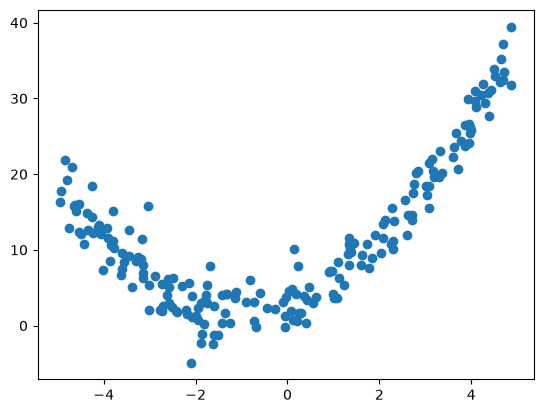

In [5]:
plt.scatter(x_train,y_train)

R2 score is 0.9112760477501196 given n=10 and lr=0.3


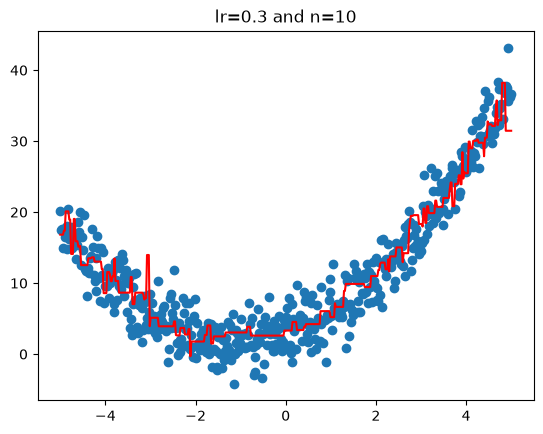

R2 score is 0.9061153998161012 given n=25 and lr=0.3


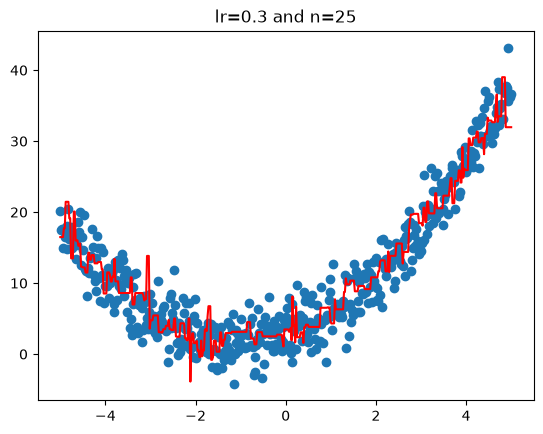

R2 score is 0.8954428324536221 given n=50 and lr=0.3


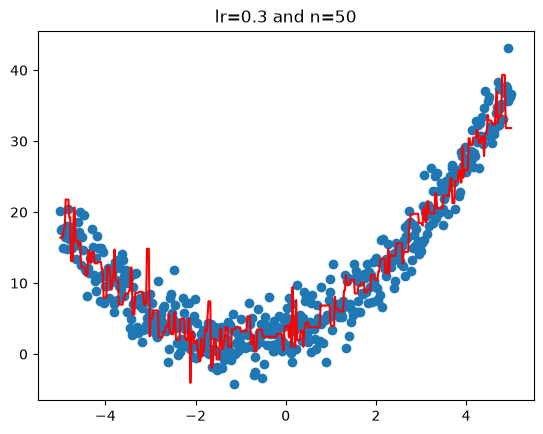

R2 score is 0.8863177849852037 given n=100 and lr=0.3


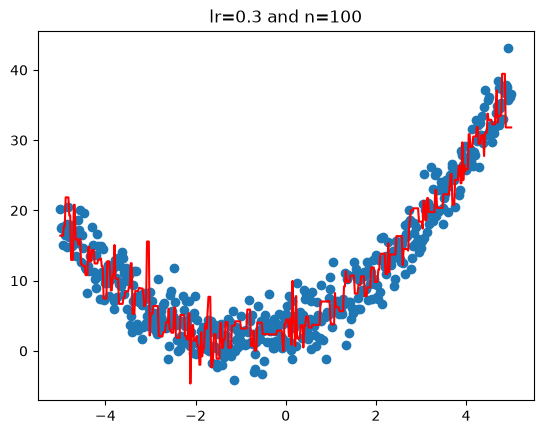

R2 score is 0.9079895075211547 given n=20 and lr=0.3


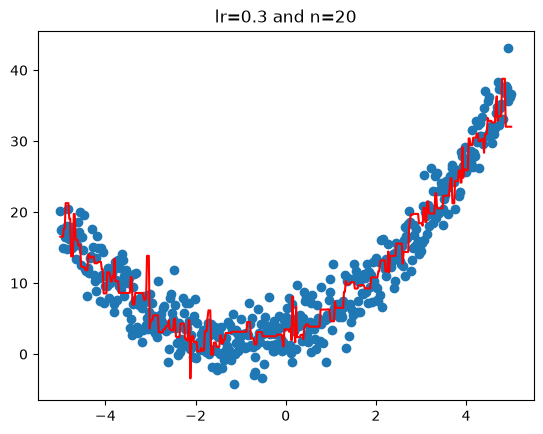

R2 score is 0.9087729072192818 given n=10 and lr=0.5


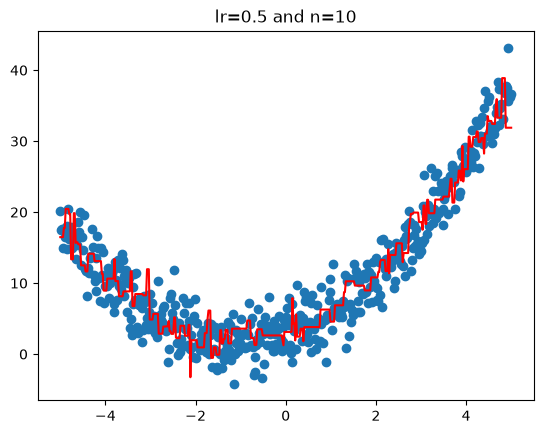

R2 score is 0.8955996922998584 given n=25 and lr=0.5


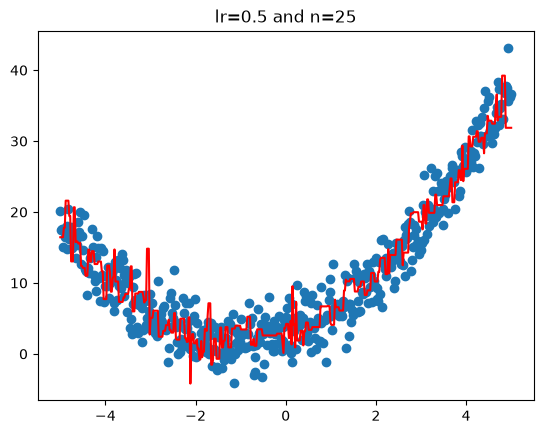

R2 score is 0.8867511375241006 given n=50 and lr=0.5


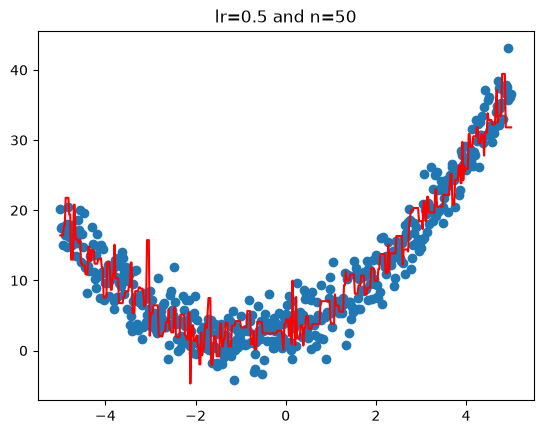

R2 score is 0.8829249800429381 given n=100 and lr=0.5


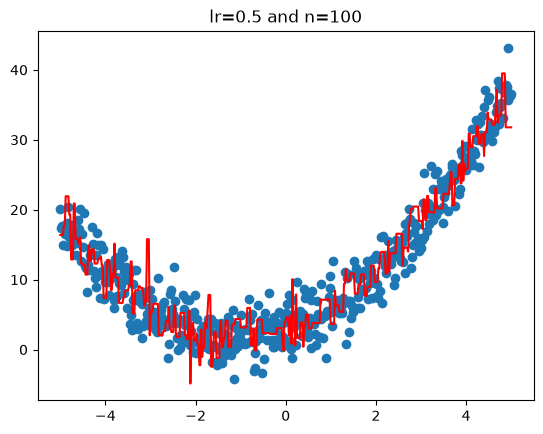

R2 score is 0.8984587998789063 given n=20 and lr=0.5


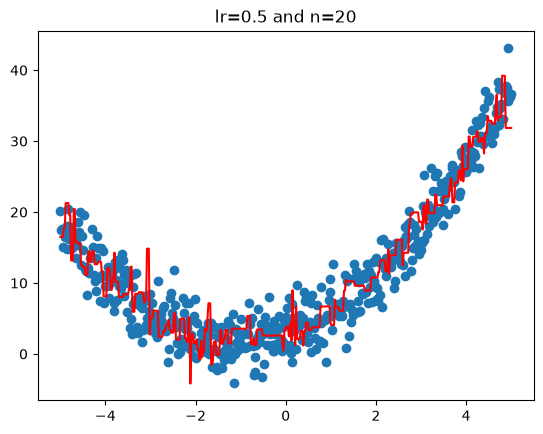

R2 score is 0.8998433362041919 given n=10 and lr=0.7


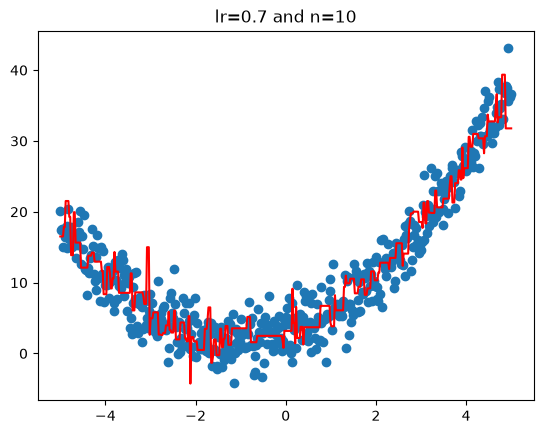

R2 score is 0.8887806665824268 given n=25 and lr=0.7


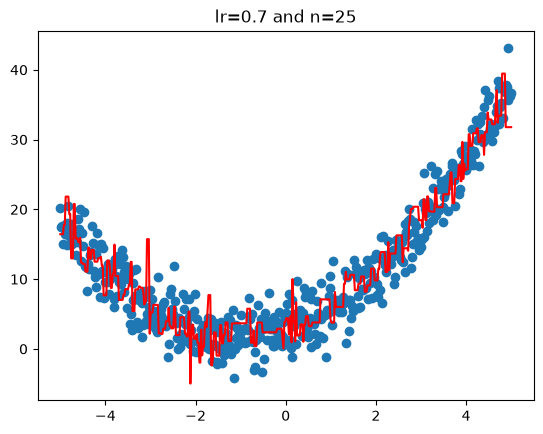

R2 score is 0.8831441429268834 given n=50 and lr=0.7


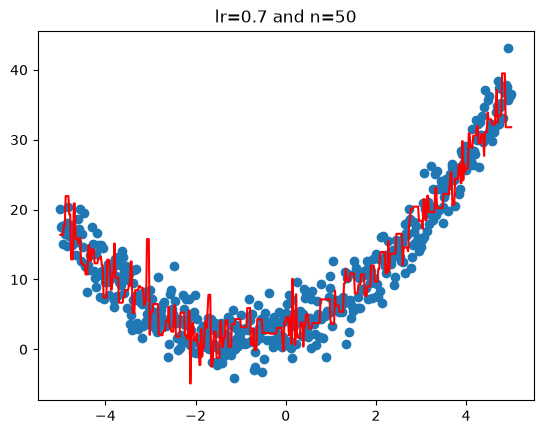

R2 score is 0.882381645834797 given n=100 and lr=0.7


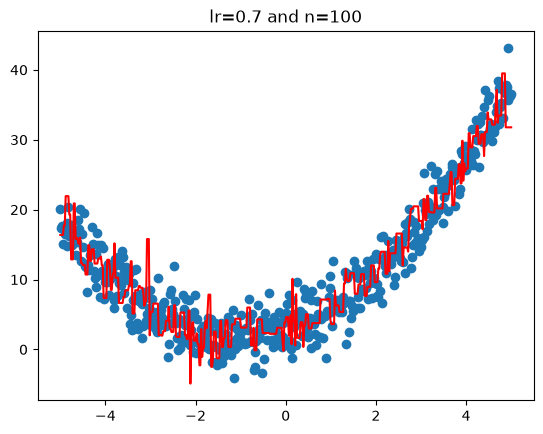

R2 score is 0.8912801773112577 given n=20 and lr=0.7


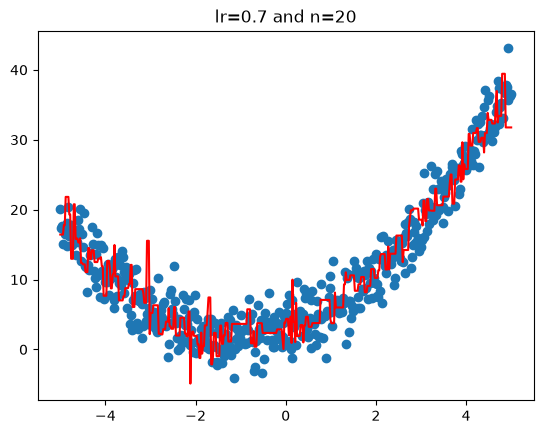

R2 score is 0.889164340071664 given n=10 and lr=1.0


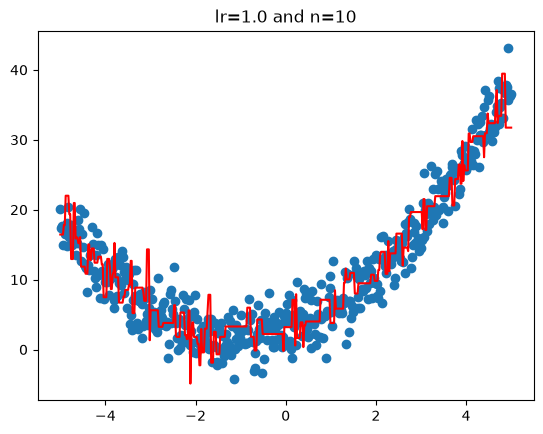

R2 score is 0.8823605513740022 given n=25 and lr=1.0


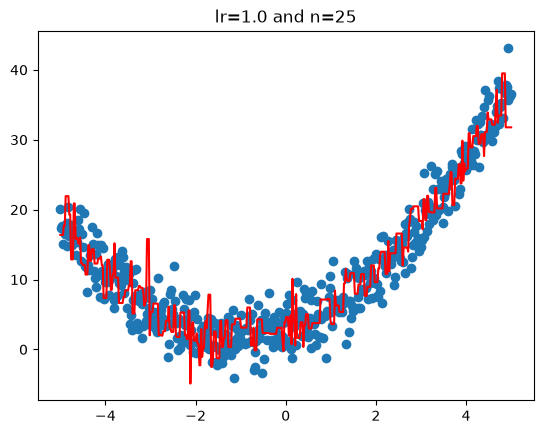

R2 score is 0.8823667882055353 given n=50 and lr=1.0


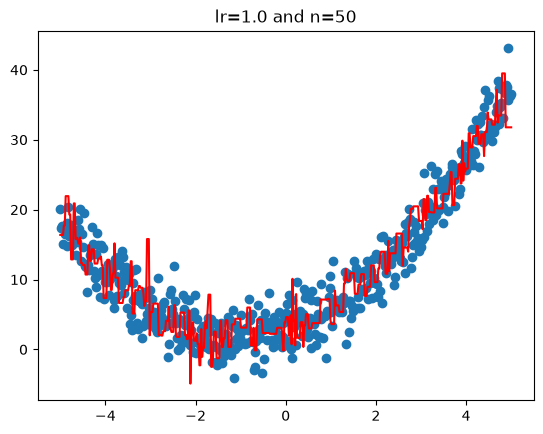

R2 score is 0.8823667882055353 given n=100 and lr=1.0


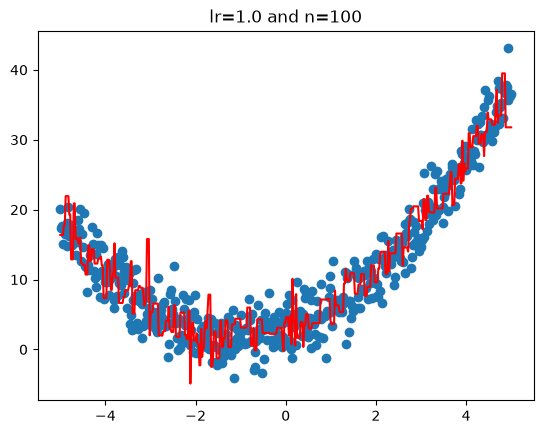

R2 score is 0.8823404483726053 given n=20 and lr=1.0


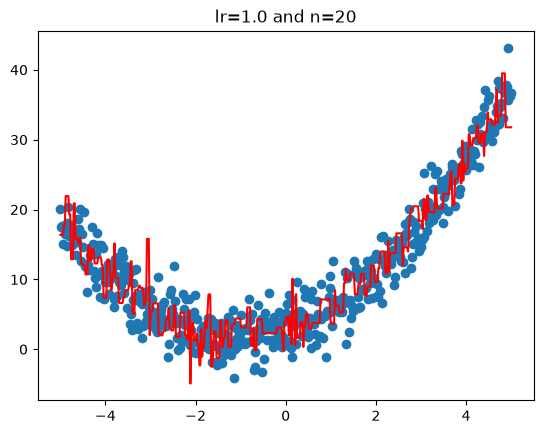

R2 score is -0.06305939953625272 given n=10 and lr=2


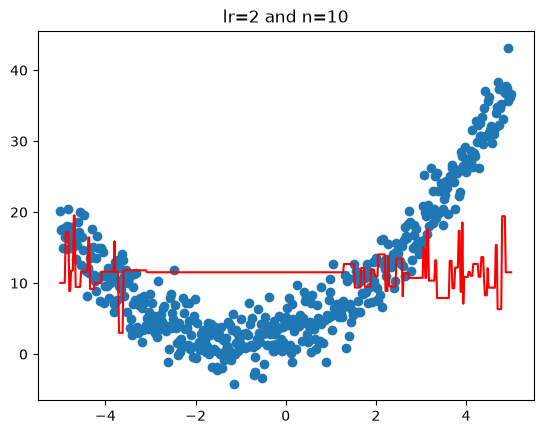

R2 score is -0.0007569435817931236 given n=25 and lr=2


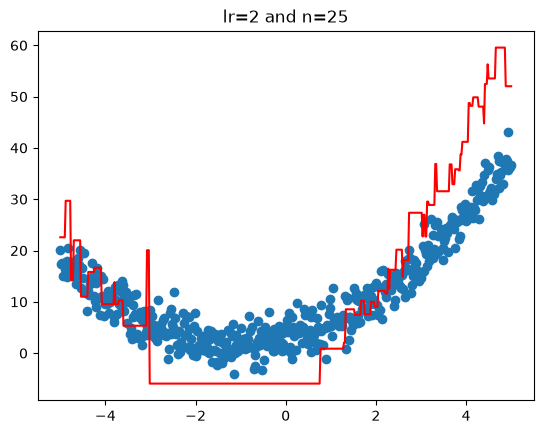

R2 score is -0.06305939953625272 given n=50 and lr=2


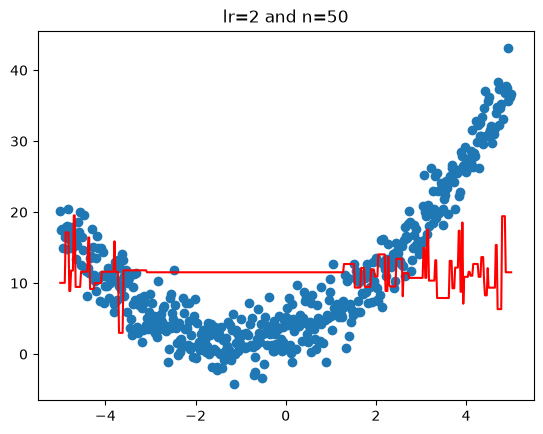

R2 score is -0.06305939953625272 given n=100 and lr=2


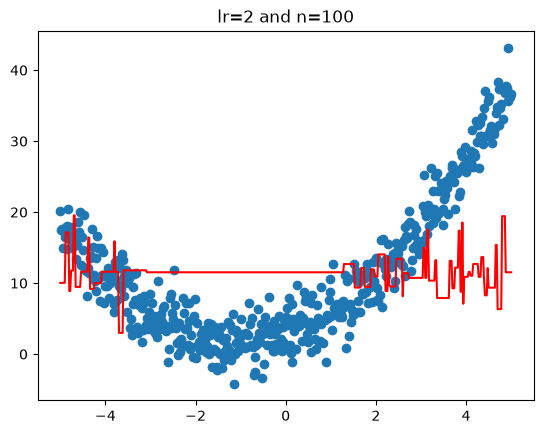

R2 score is -0.06305939953625272 given n=20 and lr=2


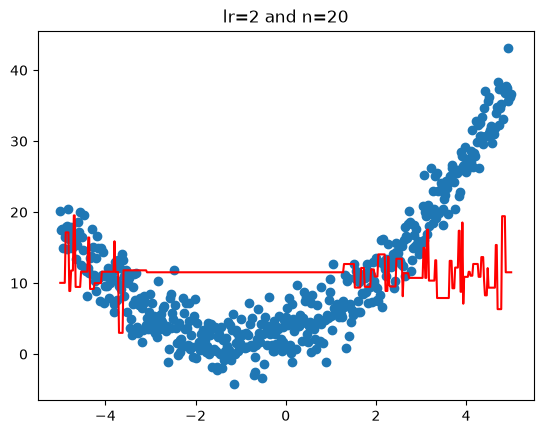

In [6]:
for lr in [0.3,0.5,0.7,1.0,2]:
    for n in [10,25,50,100,20]:
        gb = GradientBoostRegressor(learning_rate=lr,n_estimators=n)
        gb.fit(x_train,y_train)
        y_pred = gb.predict(x_test)
        print(f"R2 score is {r2_score(y_test,y_pred)} given n={n} and lr={lr}")
        plt.scatter(x_test,y_test)
        plt.plot(x_test,y_pred,c='r')
        plt.title(f"lr={lr} and n={n}")
        plt.show()

It can be clearly seen that learning rate > 1.0 gives terrible result !

# Sklearn implementation Using GridSearchCV

In [7]:
grb = GradientBoostingRegressor(loss='squared_error',random_state=42)
params = dict()
params['learning_rate'] = [0.3,0.5,0.75,1.0,2.0]
params['n_estimators'] = [20,50,100,200]
params['max_depth'] = [1,3,5,7,10]

grid = GridSearchCV(estimator=grb,param_grid=params,n_jobs=-1,scoring='r2',cv=7)
grid.fit(x_train,y_train)
print(f"Best score is {grid.best_score_}")
print(f"Best parameters are {grid.best_params_}")
# making the optimised model:
clf1 = GradientBoostingRegressor(learning_rate=0.3,loss='squared_error',random_state=42,max_depth=1,n_estimators=50)
clf1.fit(x_train,y_train)
print(f"r2 score on test set is {r2_score(y_test,clf1.predict(x_test))}")

Best score is 0.918317622015832
Best parameters are {'learning_rate': 0.3, 'max_depth': 1, 'n_estimators': 50}
r2 score on test set is 0.924661975168055


In [8]:
# Comparing performance on same parameters:
clf2 = GradientBoostRegressor(learning_rate=0.3,max_depth=1,n_estimators=50)
clf2.fit(x_train,y_train)
print(f"r2 score on test set is {r2_score(y_test,clf2.predict(x_test))}")

r2 score on test set is 0.924661975168055


We are getting same performance in sklearn and our own class as well.

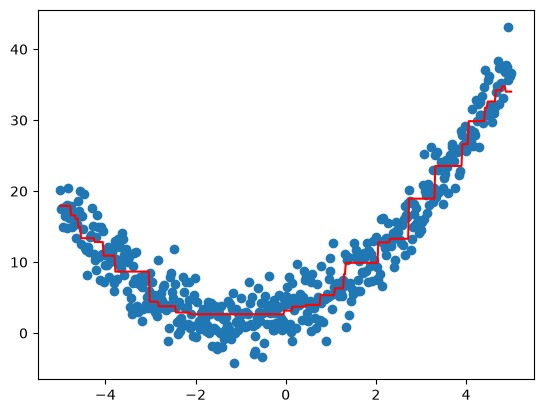

In [9]:
# plotting the optimised regression line:
plt.scatter(x_test,y_test)
plt.plot(x_test,clf2.predict(x_test),c='r')